# DAQ into pandas

A run into a DataFrame, scaled by the board's record.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


In [3]:
daq = device.daq
daq.open()
daq.enable()
device.set_time_from_pc(reference='pc')
daq.configure('phaseU', 'phaseV', 'phaseW', 'DC bus', 'NTC', sample_rate=100)
daq.start()
records = daq.read(300)
daq.stop()
print(len(records), 'records;', daq.channel_names(records[0]))

300 records; ['Phase U', 'Phase V', 'Phase W', 'NTC', 'DC bus']


`scaled=True` adds one column per channel in real units beside the codes, through the board's own converters and the channel trims in its calibration record (invariant 7). `stored` says whether that record was ever written or is the schematic's arithmetic; an uncalibrated board answers an empty record and every converter falls back to the compiled-in constant, which is what `name` says.

In [4]:
cal = device.calibration.read()
print('record stored:', cal['stored'], ' version:', cal['version'],
      ' params held:', len(cal['params']))
for name, params in sorted(device.analog.scaling().items()):
    print('%-8s %s' % (name, params.name))
print('channel trims:', [(c['index'], c['offset_raw'], c['gain_ppm'])
                         for c in cal['channels'][:3]])

record stored: False  version: 0  params held: 0
dcbus    compiled-in fallback, the board sent no record
ntc      compiled-in fallback, the board sent no record
phase    compiled-in fallback, the board sent no record
rail5    compiled-in fallback, the board sent no record
vgate    compiled-in fallback, the board sent no record
channel trims: [(0, 0, 0), (1, 0, 0), (2, 0, 0)]


In [5]:
df = daq.frame(records, index='elapsed', scaled=True)
df.head()

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
elapsed,,,,,,,,,,,,,,,,,,,,,
0.00,-5049.730769,632.576923,-1846.307692,46563.769231,21521.807692,1.0,1.0,0.474503,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-31.965892,4.004349,-11.687528,50.644204,25.664204
0.01,-5061.192308,618.307692,-1839.500000,46562.038462,21524.538462,1.0,1.0,0.509441,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-32.038446,3.914022,-11.644434,50.640221,25.667460
0.02,-5075.769231,634.615385,-1834.730769,46568.653846,21529.653846,1.0,1.0,0.509050,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-32.130721,4.017253,-11.614244,50.655445,25.673560
0.03,-5055.192308,635.038462,-1836.269231,46555.576923,21510.230769,1.0,1.0,0.493183,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-32.000464,4.019931,-11.623983,50.625356,25.650399
0.04,-5057.230769,632.269231,-1844.576923,46566.423077,21527.730769,1.0,1.0,0.534028,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-32.013368,4.002401,-11.676572,50.650311,25.671267


In [6]:
df.describe().round(3)

,Phase U,Phase V,Phase W,NTC,DC bus,AFE_ON,nFAULT/TIM1_BKIN,KEEPALIVE,TIM1_CH1N/PWMUL,TIM1_CH1/PWMUH,...,TIM1_CH2/PWMVH,TIM1_CH3N/PWMWL,TIM1_CH3/PWMWH,time,dt,Phase U (A),Phase V (A),Phase W (A),NTC (C),DC bus (V)
count,300.000,300.000,300.000,300.000,300.000,300.0,300.0,300.000,300.0,300.0,...,300.0,300.0,300.0,3.000000e+02,300.00,300.000,300.000,300.000,300.000,300.000
mean,-6763.132,-1748.814,2243.466,46152.860,20938.694,1.0,1.0,0.500,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-42.812,-11.070,14.202,49.712,24.969
std,789.610,2015.368,2687.922,308.118,394.973,0.0,0.0,0.020,0.0,0.0,...,0.0,0.0,0.0,8.670000e-01,0.00,4.998,12.758,17.015,0.694,0.471
min,-7616.654,-6044.154,-1846.308,45519.192,20191.808,1.0,1.0,0.441,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-48.215,-38.261,-11.688,48.295,24.078
25%,-7478.192,-3313.125,-83.510,45904.250,20603.673,1.0,1.0,0.487,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-47.339,-20.973,-0.529,49.149,24.569
50%,-7017.000,-1065.212,1814.115,46234.692,21012.077,1.0,1.0,0.501,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-44.419,-6.743,11.484,49.893,25.056
75%,-6162.971,-23.904,4640.683,46416.308,21276.231,1.0,1.0,0.514,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-39.013,-0.151,29.377,50.306,25.371
max,-5048.923,642.500,6967.962,46568.654,21529.654,1.0,1.0,0.551,0.0,0.0,...,0.0,0.0,0.0,1.788412e+09,0.01,-31.961,4.067,44.109,50.655,25.674


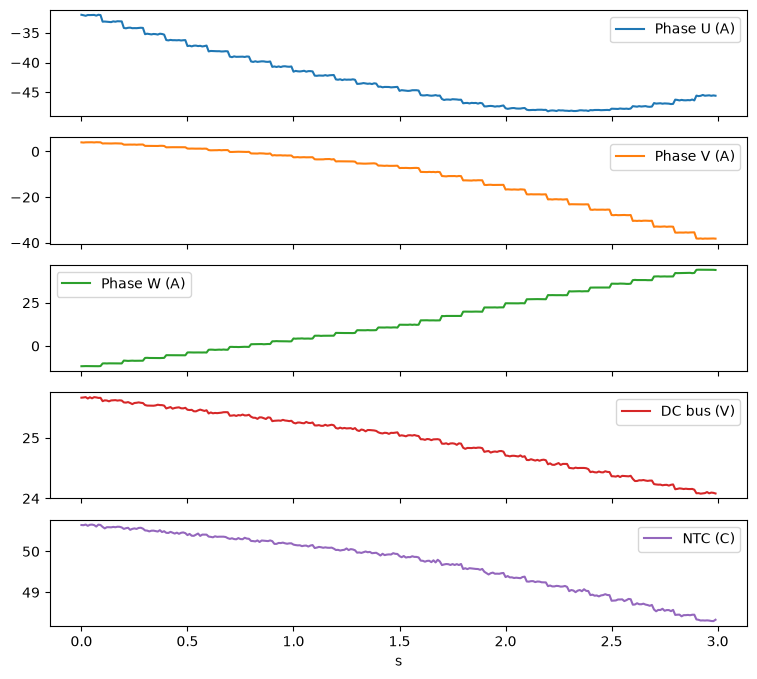

In [7]:
import matplotlib.pyplot as plt

units = [c for c in df.columns if c.endswith('(A)')]
axes = df[units + ['DC bus (V)', 'NTC (C)']].plot(subplots=True, figsize=(9, 8), legend=True)
axes[-1].set_xlabel('s')
plt.show()

The codes stay in the frame under the board's own channel names, so a tare or a span can be checked against what arrived.

In [8]:
print(df[['Phase U', 'Phase U (A)', 'NTC', 'NTC (C)']].iloc[:3])
device.close()

             Phase U  Phase U (A)           NTC    NTC (C)
elapsed                                                   
0.00    -5049.730769   -31.965892  46563.769231  50.644204
0.01    -5061.192308   -32.038446  46562.038462  50.640221
0.02    -5075.769231   -32.130721  46568.653846  50.655445


## Conclusions

In [9]:
codes = [c for c in df.columns if not c.endswith(')')]
scaled = [c for c in df.columns if c.endswith(')')]
print('%d records, %d code columns, %d scaled columns' % (len(df), len(codes), len(scaled)))
for name in ('Phase U', 'DC bus', 'NTC'):
    unit = [c for c in scaled if c.startswith(name)][0]
    span = df[unit].max() - df[unit].min()
    print('%-8s codes %8.1f +/- %6.1f   %-12s %8.3f +/- %.3f  span %.3f'
          % (name, df[name].mean(), df[name].std(), unit, df[unit].mean(),
             df[unit].std(), span))

300 records, 16 code columns, 5 scaled columns
Phase U  codes  -6763.1 +/-  789.6   Phase U (A)   -42.812 +/- 4.998  span 16.254
DC bus   codes  20938.7 +/-  395.0   DC bus (V)     24.969 +/- 0.471  span 1.595
NTC      codes  46152.9 +/-  308.1   NTC (C)        49.712 +/- 0.694  span 2.360


A code column is what arrived; the column beside it is what it means. The conversion is the board's own (invariant 7): every scaling parameter lives in the calibration record and `frame(scaled=True)` asks `board.analog.scaling()` for it rather than holding a constant, then applies that channel's stored offset and gain trim. Keeping both is deliberate - what arrived and what it means are two columns, not one that quietly became the other, and a tare that stored an offset no column used is exactly the failure that shape prevents.

With an empty record every converter falls back to the compiled-in constant and says so in `name`. `calibration.span(index, reference)` is what writes a channel's gain trim against an instrument, and it takes the reference in that channel's own unit - milliamperes for a phase, millivolts for the DC link. The DC link's stands at -32 418 ppm, 31.04 V read against 30.05 V true (FINDINGS).

The DC link's divider is 49.9k/2.2k: 78.15 V full scale on a 63 V rating, 24 % of headroom kept on purpose so an over-rating transient is recorded rather than clipped (invariant 11).